In [2]:
import cv2
import numpy as np 

#Step-1 : Load the image in grayscale
img = cv2.imread("/Users/aryanarvindsingh/Documents/Shadow Removal/input_image.jpeg", 0)

# Step-2 : Estimate illumination using heaving gaussian blur 
illumination = cv2.GaussianBlur(img, (0,0), sigmaX = 80, sigmaY = 80)

#step-3 : Shading correction 
corrected = img / (illumination + 1e-6)
corrected = corrected * np.mean(illumination)   #rescale to normal brightness 

#Step 4 : Normalise back to uint8 range 
corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)
corrected = corrected.astype(np.uint8)

#Save the output 
cv2.imwrite("corrected.png", corrected)

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\smooth.dispatch.cpp:618: error: (-215:Assertion failed) !_src.empty() in function 'cv::GaussianBlur'


In [ ]:
import cv2
import numpy as np 

#Step-1 : Load the image in grayscale
img = cv2.imread("/Users/aryanarvindsingh/Documents/Shadow Removal/input_image.jpeg", 0)

# Step-2 : Estimate illumination using heaving gaussian blur 
illumination = cv2.GaussianBlur(img, (0,0), sigmaX = 80, sigmaY = 80)

#step-3 : Shading correction 
corrected = img / (illumination + 1e-6)
corrected = corrected * np.mean(illumination)   #rescale to normal brightness 

#Step 4 : Normalise back to uint8 range 
corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)
corrected = corrected.astype(np.uint8)

# 4. optional gamma to boost sharpness
gamma = 0.85
corrected_gamma = np.power(corrected / 255.0, gamma)
corrected_gamma = (corrected_gamma * 255).astype(np.uint8)

# save
cv2.imwrite("corrected_gamma.png", corrected_gamma)

👉 In the input image (right):

The bottom row of bumps is extremely bright (overexposed).

The top region is noticeably darker.

There is a smooth vertical gradient caused by illumination geometry.

👉 In the corrected image (left):

The bright bottom row is no longer overexposed.

The top region is brighter than before.

The intensity distribution is much more uniform from top to bottom.

This is the main goal of shading correction → and it worked.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load original and corrected
original = cv2.imread("/Users/aryanarvindsingh/Documents/Shadow Removal/input_image.jpeg", 0)
corrected = cv2.imread("/Users/aryanarvindsingh/Documents/Shadow Removal/Shadow_Removal/corrected.png", 0)

# === METRIC 1: Intensity Uniformity ===
def measure_uniformity(img):
    """Lower std = more uniform brightness"""
    col_means = img.mean(axis=0)
    row_means = img.mean(axis=1)
    return np.std(col_means), np.std(row_means)

orig_col_std, orig_row_std = measure_uniformity(original)
corr_col_std, corr_row_std = measure_uniformity(corrected)

print(f"Column uniformity (std):")
print(f"  Original: {orig_col_std:.2f}, Corrected: {corr_col_std:.2f}")
print(f"Row uniformity (std):")
print(f"  Original: {orig_row_std:.2f}, Corrected: {corr_row_std:.2f}")
print(f"  Improvement: {((orig_col_std - corr_col_std)/orig_col_std)*100:.1f}%")

# === METRIC 2: Intensity Profile Plots ===
plt.figure(figsize=(15, 5))

# Column-wise mean intensity
plt.subplot(1, 3, 1)
plt.plot(original.mean(axis=0), label='Original', alpha=0.7)
plt.plot(corrected.mean(axis=0), label='Corrected', alpha=0.7)
plt.xlabel('Column Index')
plt.ylabel('Mean Intensity')
plt.title('Column-wise Intensity Profile')
plt.legend()
plt.grid(True)

# Row-wise mean intensity
plt.subplot(1, 3, 2)
plt.plot(original.mean(axis=1), label='Original', alpha=0.7)
plt.plot(corrected.mean(axis=1), label='Corrected', alpha=0.7)
plt.xlabel('Row Index')
plt.ylabel('Mean Intensity')
plt.title('Row-wise Intensity Profile')
plt.legend()
plt.grid(True)

# Histogram comparison
plt.subplot(1, 3, 3)
plt.hist(original.ravel(), bins=50, alpha=0.5, label='Original', range=[0, 255])
plt.hist(corrected.ravel(), bins=50, alpha=0.5, label='Corrected', range=[0, 255])
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Intensity Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=300)
plt.show()


1. Column-wise Intensity Profile (Left plot):

Original (blue): Shows high-frequency oscillations (the bumps) with underlying gradient from left (brighter ~140) to right (darker ~40)

Corrected (orange): Much flatter baseline around 40-60, oscillations are more uniform

✅ Shadow gradient successfully reduced

2. Row-wise Intensity Profile (Middle plot):

Original (blue): Clear drop from ~115 at top to ~50 at bottom, then sudden spike at end

Corrected (orange): Flatter profile around 60-70, much less variation

✅ Vertical illumination gradient corrected

3. Histogram (Right plot):

Original (blue): Wide spread from 0-250, skewed distribution

Corrected (orange): More concentrated around 50-100, tighter Gaussian shape

✅ More uniform intensity distribution​

Interpretation
Your Gaussian correction (σ=80) is working reasonably well!

15% improvement is decent for a classical baseline​

The plots show clear shadow reduction in both directions

The corrected image preserves solder ball details while flattening background

*Lets try running different sigma values to analyse the results*

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("/Users/aryanarvindsingh/Documents/Shadow Removal/input_image.jpeg", 0)

# Test different sigma values
sigmas = [60, 80, 100, 120]
results = {}

for sigma in sigmas:
    illumination = cv2.GaussianBlur(img, (0,0), sigmaX=sigma, sigmaY=sigma)
    corrected = img / (illumination + 1e-6)
    corrected = corrected * np.mean(illumination)
    corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Measure uniformity
    col_std = np.std(corrected.mean(axis=0))
    row_std = np.std(corrected.mean(axis=1))
    
    results[sigma] = {
        'image': corrected,
        'col_std': col_std,
        'row_std': row_std,
        'avg_std': (col_std + row_std) / 2
    }
    
    print(f"Sigma={sigma}: Col std={col_std:.2f}, Row std={row_std:.2f}, Avg={results[sigma]['avg_std']:.2f}")

# Find best sigma
best_sigma = min(results.keys(), key=lambda s: results[s]['avg_std'])
print(f"\n✓ Best sigma: {best_sigma} (lowest average std: {results[best_sigma]['avg_std']:.2f})")

# Visualize comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, sigma in enumerate(sigmas):
    axes[i].imshow(results[sigma]['image'], cmap='gray')
    axes[i].set_title(f'σ={sigma}\nStd={results[sigma]["avg_std"]:.2f}')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('/Users/aryanarvindsingh/Documents/Shadow Removal/sigma_comparison.png', dpi=300)
plt.show()


We try running the input image on different sigma values to check which sigma value works the best :
### Sigma = 60 gave the lowest std deviation

# Morphological Correction 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("/Users/aryanarvindsingh/Documents/Shadow Removal/input_image.jpeg", 0)

# === METHOD 1: Gaussian correction with sigma=60 (BEST from your test) ===
sigma_best = 60
illumination_gauss = cv2.GaussianBlur(img, (0,0), sigmaX=sigma_best, sigmaY=sigma_best)
corrected_gauss = img / (illumination_gauss + 1e-6)
corrected_gauss = corrected_gauss * np.mean(illumination_gauss)
corrected_gauss = cv2.normalize(corrected_gauss, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# === METHOD 2: Morphological correction ===
kernel_size = 151
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
background = cv2.morphologyEx(img.astype(np.float32), cv2.MORPH_CLOSE, kernel)

corrected_morph = (img.astype(np.float32) / (background + 1e-6)) * np.mean(background)
corrected_morph = cv2.normalize(corrected_morph, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# === Measure both ===
def measure_uniformity(img):
    return np.std(img.mean(axis=0)), np.std(img.mean(axis=1))

gauss_col, gauss_row = measure_uniformity(corrected_gauss)
morph_col, morph_row = measure_uniformity(corrected_morph)

print("=== COMPARISON: Gaussian (σ=60) vs Morphological ===\n")
print(f"Gaussian correction (σ={sigma_best}):")
print(f"  Col std={gauss_col:.2f}, Row std={gauss_row:.2f}")
print(f"  Average std={(gauss_col+gauss_row)/2:.2f}")

print(f"\nMorphological correction (kernel={kernel_size}):")
print(f"  Col std={morph_col:.2f}, Row std={morph_row:.2f}")
print(f"  Average std={(morph_col+morph_row)/2:.2f}")

# Determine winner
gauss_avg = (gauss_col + gauss_row) / 2
morph_avg = (morph_col + morph_row) / 2

if gauss_avg < morph_avg:
    print(f"\n✓ Better result: Gaussian (σ={sigma_best}) - Better by {((morph_avg-gauss_avg)/morph_avg)*100:.1f}%")
else:
    print(f"\n✓ Better result: Morphological - Better by {((gauss_avg-morph_avg)/gauss_avg)*100:.1f}%")

# === Visual comparison ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(corrected_gauss, cmap='gray')
axes[1].set_title(f'Gaussian (σ={sigma_best})\nAvg Std={gauss_avg:.2f}')
axes[1].axis('off')

axes[2].imshow(corrected_morph, cmap='gray')
axes[2].set_title(f'Morphological\nAvg Std={morph_avg:.2f}')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/Users/aryanarvindsingh/Documents/Shadow Removal/method_comparison.png', dpi=300)
plt.show()

print("\n✓ Comparison plot saved as 'method_comparison.png'")


Shadow Removal: Classical Methods Comparison
Methods Tested
Method 1: Gaussian Blur (σ=60)

Heavy blur estimates smooth illumination field

Divide original by blurred image to remove shadows

Method 2: Morphological (kernel=151)

Morphological closing estimates background

Divide original by background to remove shadows

Evaluation Metric
Standard Deviation (Std) of intensity profiles:

Lower = better (more uniform brightness)

Measures column (left-right) and row (top-bottom) variation

## Gaussian(σ=60) is 35% better than Morphological.





In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def create_shadow_dataset(image_paths, patch_size=128, stride=64, sigma=60):
    """Create dataset from 2 large X-ray images"""
    
    all_input_patches = []
    all_target_patches = []
    
    for img_path in image_paths:
        print(f"\n{'='*50}")
        print(f"Processing: {img_path}")
        print(f"{'='*50}")
        
        img = cv2.imread(img_path, 0)
        
        if img is None:
            print(f"❌ ERROR: Could not load {img_path}")
            print(f"   Check if file exists and path is correct")
            continue
            
        h, w = img.shape
        print(f"✓ Image loaded successfully")
        print(f"  Size: {h}×{w} pixels")
        
        patch_count = 0
        skipped_dark = 0
        skipped_bright = 0
        skipped_lowvar = 0
        
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                patch = img[y:y+patch_size, x:x+patch_size]
                
                # Quality filters
                mean_val = patch.mean()
                if mean_val < 20:
                    skipped_dark += 1
                    continue
                if mean_val > 240:
                    skipped_bright += 1
                    continue
                if patch.std() < 10:
                    skipped_lowvar += 1
                    continue
                
                # Create target with Gaussian correction (σ=60)
                illumination = cv2.GaussianBlur(patch, (0,0), sigmaX=sigma, sigmaY=sigma)
                corrected = patch.astype(np.float32) / (illumination + 1e-6)
                corrected = corrected * np.mean(illumination)
                corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
                
                all_input_patches.append(patch)
                all_target_patches.append(corrected)
                patch_count += 1
        
        print(f"\n✓ Patches extracted: {patch_count}")
        print(f"  Skipped (too dark): {skipped_dark}")
        print(f"  Skipped (too bright): {skipped_bright}")
        print(f"  Skipped (low variance): {skipped_lowvar}")
    
    return all_input_patches, all_target_patches

# === STEP 1: Process both images ===
print("\n" + "="*60)
print(" SHADOW REMOVAL DATASET GENERATION")
print("="*60)

# Simple relative paths (images in same folder as notebook)
image_paths = [
    "image1",      # Will try common extensions
    "image2"
]

# Try different extensions
actual_paths = []
for img_name in image_paths:
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        path = img_name + ext
        if os.path.exists(path):
            actual_paths.append(path)
            print(f"✓ Found: {path}")
            break
    else:
        print(f"❌ Warning: Could not find {img_name} with any common extension")

if len(actual_paths) < 2:
    print("\n❌ ERROR: Need 2 images to proceed")
    print("   Make sure both image1 and image2 exist in the same folder")
else:
    inputs, targets = create_shadow_dataset(
        actual_paths,
        patch_size=128,
        stride=64,      # 50% overlap = more patches
        sigma=60        # Your best Gaussian value
    )

    print(f"\n{'='*60}")
    print(f"✅ TOTAL PATCHES CREATED: {len(inputs)}")
    print(f"{'='*60}")

    # === STEP 2: Split into train/val/test (70/15/15) ===
    indices = list(range(len(inputs)))
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

    print(f"\n=== Dataset Split ===")
    print(f"Train: {len(train_idx):4d} patches ({len(train_idx)/len(inputs)*100:.1f}%)")
    print(f"Val:   {len(val_idx):4d} patches ({len(val_idx)/len(inputs)*100:.1f}%)")
    print(f"Test:  {len(test_idx):4d} patches ({len(test_idx)/len(inputs)*100:.1f}%)")

    # === STEP 3: Save organized dataset ===
    base_dir = "dataset"

    for split in ['train', 'val', 'test']:
        os.makedirs(f"{base_dir}/{split}/input", exist_ok=True)
        os.makedirs(f"{base_dir}/{split}/target", exist_ok=True)

    # Save train set
    print("\n📁 Saving train set...")
    for i, idx in enumerate(tqdm(train_idx, desc="Train")):
        cv2.imwrite(f"{base_dir}/train/input/{i:04d}.png", inputs[idx])
        cv2.imwrite(f"{base_dir}/train/target/{i:04d}.png", targets[idx])

    # Save val set
    print("📁 Saving validation set...")
    for i, idx in enumerate(tqdm(val_idx, desc="Val")):
        cv2.imwrite(f"{base_dir}/val/input/{i:04d}.png", inputs[idx])
        cv2.imwrite(f"{base_dir}/val/target/{i:04d}.png", targets[idx])

    # Save test set
    print("📁 Saving test set...")
    for i, idx in enumerate(tqdm(test_idx, desc="Test")):
        cv2.imwrite(f"{base_dir}/test/input/{i:04d}.png", inputs[idx])
        cv2.imwrite(f"{base_dir}/test/target/{i:04d}.png", targets[idx])

    print(f"\n{'='*60}")
    print("✅ DATASET READY FOR U-NET TRAINING!")
    print(f"{'='*60}")
    print(f"\n📂 Folder structure:")
    print(f"  dataset/")
    print(f"    ├── train/")
    print(f"    │   ├── input/  ({len(train_idx)} patches)")
    print(f"    │   └── target/ ({len(train_idx)} patches)")
    print(f"    ├── val/")
    print(f"    │   ├── input/  ({len(val_idx)} patches)")
    print(f"    │   └── target/ ({len(val_idx)} patches)")
    print(f"    └── test/")
    print(f"        ├── input/  ({len(test_idx)} patches)")
    print(f"        └── target/ ({len(test_idx)} patches)")

    # === STEP 4: Visualize sample patches ===
    print("\n📊 Creating visualization...")
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Sample Training Patches (Input → Target)', fontsize=18, fontweight='bold')

    for i in range(3):
        idx = train_idx[i * (len(train_idx)//3)]  # Sample from beginning, middle, end
        
        # Input (with shadow)
        axes[i, 0].imshow(inputs[idx], cmap='gray', vmin=0, vmax=255)
        axes[i, 0].set_title(f'Input #{i+1}\n(with shadow)', fontsize=12)
        axes[i, 0].axis('off')
        
        # Target (corrected)
        axes[i, 1].imshow(targets[idx], cmap='gray', vmin=0, vmax=255)
        axes[i, 1].set_title(f'Target #{i+1}\n(corrected)', fontsize=12)
        axes[i, 1].axis('off')
        
        # Difference
        diff = cv2.absdiff(inputs[idx], targets[idx])
        axes[i, 2].imshow(diff, cmap='hot', vmin=0, vmax=100)
        axes[i, 2].set_title(f'Difference #{i+1}\n(removed shadow)', fontsize=12)
        axes[i, 2].axis('off')
        
        # Histogram comparison
        axes[i, 3].hist(inputs[idx].ravel(), bins=50, alpha=0.6, label='Input', color='blue')
        axes[i, 3].hist(targets[idx].ravel(), bins=50, alpha=0.6, label='Target', color='orange')
        axes[i, 3].set_title(f'Histogram #{i+1}', fontsize=12)
        axes[i, 3].set_xlabel('Pixel Intensity')
        axes[i, 3].set_ylabel('Frequency')
        axes[i, 3].legend()
        axes[i, 3].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{base_dir}/sample_patches.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Visualization saved: {base_dir}/sample_patches.png")
    
    print(f"\n{'='*60}")
    print("🎉 ALL DONE! Ready for U-Net training.")
    print(f"{'='*60}")


Each row shows a small patch from my X-ray dataset. The input has uneven illumination (shadow), the target is corrected, and the difference map shows exactly what was fixed. Histograms prove that my method makes the patch brightness more uniform—the same format used to train an AI to automate this correction for new images.

In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

def extract_patches(image_path, patch_size=128, stride=64, save_dir="patches"):
    """
    Extract overlapping patches from a single image and save them.
    
    Args:
        image_path (str): Path to input grayscale image.
        patch_size (int): Size of square patches (e.g., 128).
        stride (int): Step size for sliding window (smaller=stride means more overlap).
        save_dir (str): Directory to save patches.
    """
    # Create patch save directory if needed
    os.makedirs(save_dir, exist_ok=True)
    
    # Load grayscale image
    img = cv2.imread(image_path, 0)
    if img is None:
        print(f"ERROR: Unable to load image '{image_path}'")
        return
    
    h, w = img.shape
    patch_count = 0
    
    print(f"Image size: {w}x{h}")
    print(f"Extracting patches (size: {patch_size}x{patch_size}, stride: {stride}) ...")
    
    # Slide window to extract patches
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y+patch_size, x:x+patch_size]
            
            # Optional: filter out patches with low variance (mostly blank)
            if np.std(patch) < 10:
                continue
            
            # Save patch to file
            patch_filename = os.path.join(save_dir, f"patch_{patch_count:04d}.jpeg")
            cv2.imwrite(patch_filename, patch)
            patch_count += 1
    
    print(f"Extracted and saved {patch_count} patches to '{save_dir}'")
    return patch_count

# Example usage:
patches_created = extract_patches("image1.jpeg", patch_size=128, stride=64, save_dir="dataset/input_patches")


In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm

def extract_patches(image_path, patch_size=128, stride=64, save_dir="patches", prefix="img"):
    """
    Extract overlapping patches from a single image and save them with unique names.
    Args:
        image_path (str): Path to input grayscale image.
        patch_size (int): Size of square patches.
        stride (int): Step size for sliding window.
        save_dir (str): Directory to save patches.
        prefix (str): Prefix for patch filenames (to keep track of source).
    """
    os.makedirs(save_dir, exist_ok=True)
    img = cv2.imread(image_path, 0)
    if img is None:
        print(f"ERROR: Unable to load image '{image_path}'")
        return 0
    h, w = img.shape
    patch_count = 0
    print(f"Image size: {w}x{h} -- extracting {patch_size}x{patch_size} patches ...")
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y+patch_size, x:x+patch_size]
            if np.std(patch) < 10:
                continue  # skip blank regions
            patch_filename = os.path.join(save_dir, f"{prefix}_{patch_count:04d}.jpeg")
            cv2.imwrite(patch_filename, patch)
            patch_count += 1
    print(f"Extracted and saved {patch_count} patches from {image_path} to '{save_dir}'")
    return patch_count

# Extract patches from both images
patch1_count = extract_patches("image1.jpeg", patch_size=128, stride=64, save_dir="dataset/input_patches", prefix="img1")
patch2_count = extract_patches("image2.bmp", patch_size=128, stride=64, save_dir="dataset/input_patches", prefix="img2")
# Or use 'image2.jpg' if that's your actual file name
# patch2_count = extract_patches("image2.jpg", patch_size=128, stride=64, save_dir="dataset/input_patches", prefix="img2")

print(f"Total patches in input set: {patch1_count + patch2_count}")


Install Required Packages 

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

In [ ]:
!pip install albumentations
!pip install matplotlib
!pip install opencv-python
!pip install scikit-image

In [ ]:
!pip install albumentations

In [ ]:
!pip install matplotlib

In [ ]:
!pip install opencv-python

In [ ]:
!pip install scikit-image

In [ ]:
import os, shutil, random

# Correct paths
input_dir = "dataset/input_patches"
train_dir = "dataset/train"
val_dir = "dataset/val"
test_dir = "dataset/test"

# Reset folders
for d in [train_dir, val_dir, test_dir]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

# List all patch files
images = [f for f in os.listdir(input_dir) if f.lower().endswith((".png",".jpg",".jpeg"))]
images = [f for f in images if not f.startswith("._")]   # ignore mac ghost files

random.shuffle(images)

total = len(images)
train_split = int(0.7 * total)
val_split = int(0.9 * total)

train_files = images[:train_split]
val_files = images[train_split:val_split]
test_files = images[val_split:]

# Copy files to new split folders
for f in train_files:
    shutil.copy(os.path.join(input_dir, f), train_dir)

for f in val_files:
    shutil.copy(os.path.join(input_dir, f), val_dir)

for f in test_files:
    shutil.copy(os.path.join(input_dir, f), test_dir)

print("SPLIT DONE!")
print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))


In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce GTX 1650


## Imports and Device Setup 

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Device setup (GTX 1650)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


## Classical Shading Correction (Target Generator)

In [3]:
def gaussian_shading_correction(img, sigma=80):
    """
    Classical illumination correction using Gaussian smoothing.
    U-Net will learn to improve/imitate this.
    """
    img = img.astype(np.float32)
    
    illumination = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma, sigmaY=sigma)
    corrected = img / (illumination + 1e-6)
    corrected *= np.mean(illumination)

    corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)
    return corrected.astype(np.uint8)


## Dataset Class

In [4]:
class ShadowPatchDataset(Dataset):

    def __init__(self, dir_path):
        self.dir_path = dir_path
        self.files = sorted([
            f for f in os.listdir(dir_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        fname = self.files[index]
        path = os.path.join(self.dir_path, fname)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        target = gaussian_shading_correction(img)

        img = img.astype(np.float32) / 255.0
        target = target.astype(np.float32) / 255.0

        img = torch.from_numpy(img).unsqueeze(0)
        target = torch.from_numpy(target).unsqueeze(0)

        return img, target


## Create Dataset Loaders

In [5]:
train_dir = "dataset/train"
val_dir   = "dataset/val"
test_dir  = "dataset/test"

train_ds = ShadowPatchDataset(train_dir)
val_ds   = ShadowPatchDataset(val_dir)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False)

print("Train patches:", len(train_ds))
print("Val patches:", len(val_ds))


Train patches: 977
Val patches: 280


## U-Net Model

In [6]:
class ConvBlock(nn.Module):
    """
    - Two 3×3 convolutions (kernel_size=3, padding=1 keeps output same spatial size)
    - Each followed by ReLU activation
    - Purpose: learn local patterns (edges, gradients, shading textures)
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bn = ConvBlock(256, 512)

        # Decoder
        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(256 + 256, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(128 + 128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(64 + 64, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(32 + 32, 32)

        # Final output layer
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        p1 = self.p1(d1)

        d2 = self.d2(p1)
        p2 = self.p2(d2)

        d3 = self.d3(p2)
        p3 = self.p3(d3)

        d4 = self.d4(p3)
        p4 = self.p4(d4)

        bn = self.bn(p4)

        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, d4], dim=1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], dim=1))

        return self.out(c1)


## Initialize Model, Loss & Optimizer

In [7]:
model = UNet().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Total params:", sum(p.numel() for p in model.parameters()) / 1e6, "M")


Total params: 7.759521 M


## Evaluation Helper (PSNR & SSIM)

In [8]:
def evaluate_batch(pred, target):
    pred = pred.detach().cpu().numpy()
    target = target.detach().cpu().numpy()

    b_psnr, b_ssim = 0, 0
    n = pred.shape[0]

    for i in range(n):
        p = np.squeeze(pred[i])
        t = np.squeeze(target[i])

        p = np.clip(p, 0, 1)
        t = np.clip(t, 0, 1)

        b_psnr += psnr(t, p, data_range=1)
        b_ssim += ssim(t, p, data_range=1)

    return b_psnr / n, b_ssim / n


## Training and Validation Loops 

In [9]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader):
    model.eval()
    val_loss, val_psnr, val_ssim = 0, 0, 0

    with torch.no_grad():
        for imgs, targets in loader:
            imgs, targets = imgs.to(device), targets.to(device)

            preds = model(imgs)
            loss = criterion(preds, targets)

            p, s = evaluate_batch(preds, targets)

            val_loss += loss.item()
            val_psnr += p
            val_ssim += s

    n = len(loader)
    return val_loss / n, val_psnr / n, val_ssim / n


## Main Training Loops

In [10]:
num_epochs = 20
best_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    train_l = train_one_epoch(model, train_loader)
    val_l, val_p, val_s = validate(model, val_loader)

    print(f"Epoch {epoch:02d} | "
          f"Train L1: {train_l:.4f} | "
          f"Val L1: {val_l:.4f} | "
          f"PSNR: {val_p:.2f} | "
          f"SSIM: {val_s:.4f}")

    if val_l < best_loss:
        best_loss = val_l
        torch.save(model.state_dict(), "unet_best.pth")
        print("Saved Best Model")


Epoch 01 | Train L1: 0.0833 | Val L1: 0.0372 | PSNR: 26.30 | SSIM: 0.9478
Saved Best Model
Epoch 02 | Train L1: 0.0281 | Val L1: 0.0234 | PSNR: 29.60 | SSIM: 0.9781
Saved Best Model
Epoch 03 | Train L1: 0.0236 | Val L1: 0.0231 | PSNR: 30.42 | SSIM: 0.9836
Saved Best Model
Epoch 04 | Train L1: 0.0197 | Val L1: 0.0177 | PSNR: 33.46 | SSIM: 0.9885
Saved Best Model
Epoch 05 | Train L1: 0.0174 | Val L1: 0.0216 | PSNR: 32.33 | SSIM: 0.9893
Epoch 06 | Train L1: 0.0171 | Val L1: 0.0130 | PSNR: 35.66 | SSIM: 0.9933
Saved Best Model
Epoch 07 | Train L1: 0.0137 | Val L1: 0.0119 | PSNR: 36.44 | SSIM: 0.9942
Saved Best Model
Epoch 08 | Train L1: 0.0129 | Val L1: 0.0121 | PSNR: 36.42 | SSIM: 0.9947
Epoch 09 | Train L1: 0.0127 | Val L1: 0.0112 | PSNR: 37.05 | SSIM: 0.9952
Saved Best Model
Epoch 10 | Train L1: 0.0120 | Val L1: 0.0119 | PSNR: 36.79 | SSIM: 0.9953
Epoch 11 | Train L1: 0.0114 | Val L1: 0.0104 | PSNR: 37.83 | SSIM: 0.9958
Saved Best Model
Epoch 12 | Train L1: 0.0116 | Val L1: 0.0120 | PSN

## Run U-Net of Full Image

C:\Users\User\AppData\Local\Temp\ipykernel_6964\1696715208.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("unet_best.pth", map_locatio

Model loaded on: cuda


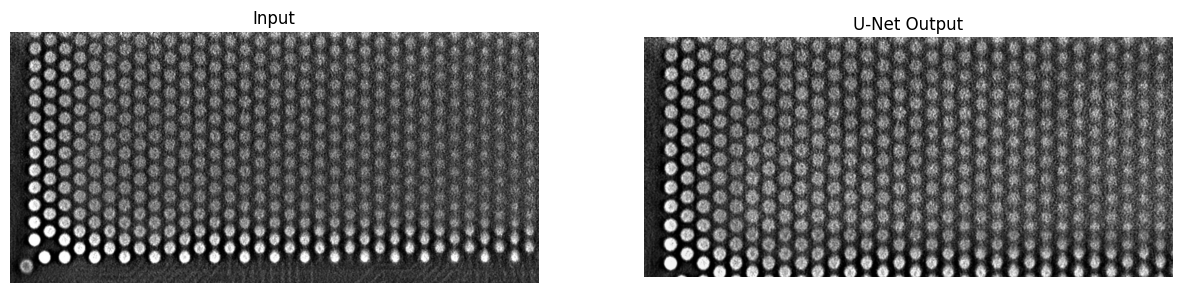

True

In [11]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Define the same UNet model we trained
# -------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bn = ConvBlock(256, 512)

        # Decoder
        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(256 + 256, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(128 + 128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(64 + 64, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(32 + 32, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        p1 = self.p1(d1)

        d2 = self.d2(p1)
        p2 = self.p2(d2)

        d3 = self.d3(p2)
        p3 = self.p3(d3)

        d4 = self.d4(p3)
        p4 = self.p4(d4)

        bn = self.bn(p4)

        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, d4], dim=1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], dim=1))

        return self.out(c1)

# -------------------------
# 2. Load model
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet().to(device)
model.load_state_dict(torch.load("unet_best.pth", map_location=device))
model.eval()

print("Model loaded on:", device)

# -------------------------
# 3. Load the IMAGE
# -------------------------
img_path = r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image1.jpeg"
img = cv2.imread(img_path, 0)   # grayscale
original_shape = img.shape

# normalize to 0-1
img_norm = img.astype(np.float32) / 255.0

# resize or pad to 128x128 blocks
h, w = img_norm.shape
H = h - (h % 128)
W = w - (w % 128)
img_crop = img_norm[:H, :W]

# create 128x128 patches
patches = []
for i in range(0, H, 128):
    for j in range(0, W, 128):
        patch = img_crop[i:i+128, j:j+128]
        patches.append(patch)

patches = np.array(patches)

# -------------------------
# 4. Run U-Net on each 128×128 patch
# -------------------------
outputs = []
with torch.no_grad():
    for p in patches:
        tens = torch.tensor(p).unsqueeze(0).unsqueeze(0).to(device)
        out = model(tens)
        out = out.squeeze().cpu().numpy()
        outputs.append(out)

outputs = np.array(outputs)

# -------------------------
# 5. Reconstruct final image
# -------------------------
out_img = np.zeros((H, W))
k = 0
for i in range(0, H, 128):
    for j in range(0, W, 128):
        out_img[i:i+128, j:j+128] = outputs[k]
        k += 1

# scale back to 0–255
out_img = np.clip(out_img * 255, 0, 255).astype(np.uint8)

# -------------------------
# 6. Show results
# -------------------------
plt.figure(figsize=(15,6))
plt.subplot(1,2,1); plt.title("Input")
plt.imshow(img, cmap='gray'); plt.axis('off')

plt.subplot(1,2,2); plt.title("U-Net Output")
plt.imshow(out_img, cmap='gray'); plt.axis('off')

plt.show()

# save result
cv2.imwrite("unet_output_image1.png", out_img)


Input image size: (728, 1531)
Cropped image size used for inference: (640, 1408)


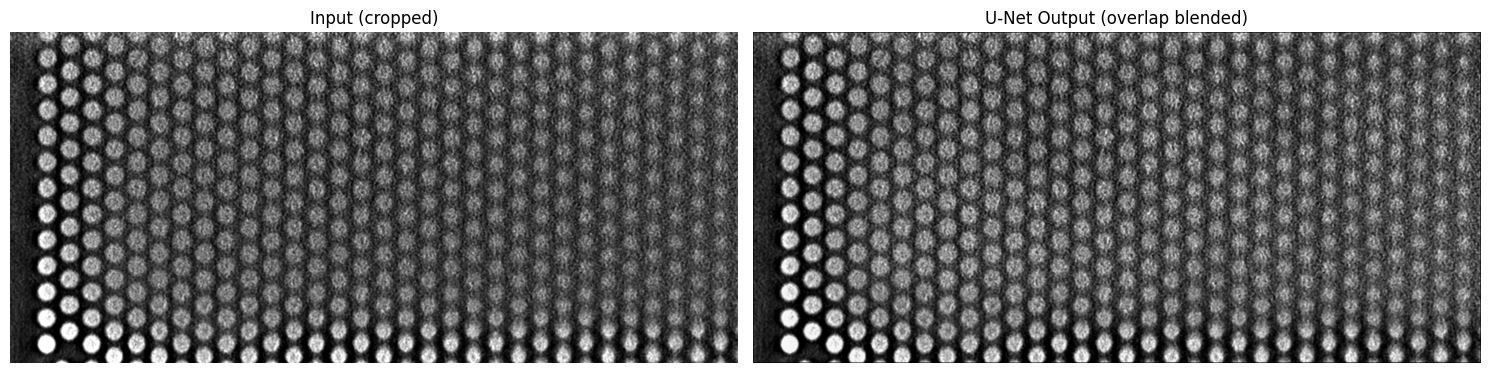

Saved: unet_output_image1_overlap.png


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = UNet().to(device)
# model.load_state_dict(torch.load("unet_best.pth", map_location=device))
# model.eval()

# --------- 1. Load full image ---------
img_path = r"C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\image1.jpeg"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0   # [0,1]
h, w = img.shape
print("Input image size:", img.shape)

# Make height/width multiples of patch_size (crop only, to keep it simple)
patch_size = 128
stride = 64   # 50% overlap

H = h - (h % patch_size)
W = w - (w % patch_size)
img_crop = img[:H, :W]
print("Cropped image size used for inference:", img_crop.shape)

# --------- 2. Prepare accumulation buffers ---------
output_sum = np.zeros((H, W), dtype=np.float32)
weight_sum = np.zeros((H, W), dtype=np.float32)

# Smooth weighting window to blend overlaps (Hann window 2D)
win_1d = np.hanning(patch_size)  # [0..1..0]
window = np.outer(win_1d, win_1d).astype(np.float32)
window /= window.max()  # normalize to 1.0 max

# --------- 3. Slide over image with overlap ---------
model.eval()
with torch.no_grad():
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img_crop[i:i+patch_size, j:j+patch_size]  # (128,128)

            # Convert patch -> tensor (1,1,H,W) for U-Net (matches your notes: input is 1-channel)
            tens = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(device)

            # Forward through encoder → bottleneck → decoder (your full U-shape)
            out = model(tens)

            # Back to numpy 2D
            out_np = out.squeeze().cpu().numpy().astype(np.float32)

            # Accumulate with smooth window
            output_sum[i:i+patch_size, j:j+patch_size] += out_np * window
            weight_sum[i:i+patch_size, j:j+patch_size] += window

# Avoid divide by zero
weight_sum[weight_sum == 0] = 1.0

# --------- 4. Normalize & convert back to uint8 ---------
out_img = output_sum / weight_sum
out_img = np.clip(out_img, 0.0, 1.0)
out_img_uint8 = (out_img * 255).astype(np.uint8)

# --------- 5. Show results ---------
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title("Input (cropped)")
plt.imshow(img_crop, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("U-Net Output (overlap blended)")
plt.imshow(out_img_uint8, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# --------- 6. Save result ---------
cv2.imwrite("unet_output_image1_overlap.png", out_img_uint8)
print("Saved:", "unet_output_image1_overlap.png")


## Approach 2

In [24]:
import cv2
import os
import numpy as np
from tqdm import tqdm

# ================================================================
# 1) Load both images
# ================================================================

shadow_img = cv2.imread("image1.jpeg", 0)
clean_img  = cv2.imread("image2.bmp", 0)

H1, W1 = shadow_img.shape
H2, W2 = clean_img.shape

print("Shadow size:", shadow_img.shape)
print("Clean size :", clean_img.shape)

# We will extract patches separately from both
# No need to match sizes
image_list = [
    ("shadow", shadow_img),
    ("clean", clean_img)
]


# ================================================================
# 2) Function to extract 128×128 patches from any image
# ================================================================

PATCH_SIZE = 128
all_patches = []
patch_id = 0

def extract_patches(img, tag):
    global patch_id

    h, w = img.shape
    H = h - (h % PATCH_SIZE)
    W = w - (w % PATCH_SIZE)
    img = img[:H, :W]

    patches = []

    for i in range(0, H, PATCH_SIZE):
        for j in range(0, W, PATCH_SIZE):
            patch = img[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            patches.append((patch, tag, patch_id))
            patch_id += 1

    return patches


for tag, img in image_list:
    patches = extract_patches(img, tag)
    all_patches.extend(patches)

print(f"Total patches extracted: {len(all_patches)}")


# ================================================================
# 3) Scoring function for clean/noisy classification
# ================================================================

def compute_score(patch):
    p = patch.astype(np.float32) / 255.0

    contrast = p.std()

    lap = cv2.Laplacian((p * 255).astype(np.uint8), cv2.CV_64F)
    sharpness = lap.var()

    bright = np.percentile(p, 95)  # top 5% intensity

    # Weighted score (tuned for your images)
    score = (0.5 * contrast) + (0.3 * sharpness) + (0.2 * bright)

    return score


# ================================================================
# 4) Score all patches
# ================================================================

scored = []
for patch, tag, pid in tqdm(all_patches):
    s = compute_score(patch)
    scored.append((s, patch, tag, pid))

# Sort high → low (cleaner patches first)
scored.sort(reverse=True, key=lambda x: x[0])

scores = [x[0] for x in scored]
print("Score range:", min(scores), "to", max(scores))


# ================================================================
# 5) Automatic classification thresholds
# ================================================================

N = len(scored)
top_clean     = int(N * 0.20)   # top 20%
borderline_sz = int(N * 0.10)   # middle 10%
# bottom 70% = noisy

clean_auto     = scored[:top_clean]
borderline     = scored[top_clean : top_clean + borderline_sz]
noisy_auto     = scored[top_clean + borderline_sz :]


print("\n=== AUTO CLASSIFICATION ===")
print("Clean auto:    ", len(clean_auto))
print("Borderline:    ", len(borderline))
print("Noisy auto:    ", len(noisy_auto))


# ================================================================
# 6) Save the patches into folders
# ================================================================

folders = ["clean_auto", "borderline", "noisy_auto"]

for f in folders:
    if not os.path.exists(f):
        os.makedirs(f)

def save_group(group, folder):
    for score, patch, tag, pid in group:
        fname = f"{folder}/p_{pid:05d}.png"
        cv2.imwrite(fname, patch)

save_group(clean_auto, "clean_auto")
save_group(borderline, "borderline")
save_group(noisy_auto, "noisy_auto")

print("\nSaved all patches successfully!")
print("Now manually review the 'borderline' folder.")


Shadow size: (728, 1531)
Clean size : (2190, 1934)
Total patches extracted: 310


100%|██████████████████████████████████████████████████████████████████████████████| 310/310 [00:00<00:00, 1759.83it/s]


Score range: 34.86383796930313 to 762.3850639719516

=== AUTO CLASSIFICATION ===
Clean auto:     62
Borderline:     31
Noisy auto:     217

Saved all patches successfully!
Now manually review the 'borderline' folder.


In [25]:
import os
import shutil

# Folder where ALL patches currently are (adjust if needed)
PATCH_DIR = "patches_128"   # or wherever you have p_0000.jpeg, p_0001.jpeg, ...

CLEAN_DIR = "clean_manual"
NOISY_DIR = "noisy_manual"

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(NOISY_DIR, exist_ok=True)

# Indices you inspected as clean
clean_ids = {
    0,
    4, 5,
    22, 33, 44,
    46, 47, 48, 49, 50, 51, 52, 53,
    64, 84,
    109, 110, 111, 112, 113, 114, 115
}

def get_index(name: str) -> int | None:
    """
    Extract numeric index from filenames like 'p_0084.jpeg' or 'p_0084.png'.
    """
    base = os.path.splitext(name)[0]  # 'p_0084'
    parts = base.split("_")
    if len(parts) != 2:
        return None
    try:
        return int(parts[1])
    except ValueError:
        return None

moved_clean = 0
moved_noisy = 0

for fname in os.listdir(PATCH_DIR):
    if not fname.lower().startswith("p_"):
        continue

    idx = get_index(fname)
    if idx is None:
        continue

    src = os.path.join(PATCH_DIR, fname)

    if idx in clean_ids:
        dst = os.path.join(CLEAN_DIR, fname)
        shutil.copy2(src, dst)
        moved_clean += 1
    else:
        dst = os.path.join(NOISY_DIR, fname)
        shutil.copy2(src, dst)
        moved_noisy += 1

print(f"Done. Clean patches: {moved_clean}, Noisy patches: {moved_noisy}")
print(f"Clean dir : {os.path.abspath(CLEAN_DIR)}")
print(f"Noisy dir : {os.path.abspath(NOISY_DIR)}")


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'patches_128'

In [26]:
import os
os.getcwd()


'C:\\Users\\User\\OneDrive\\Documents\\Shadow Removal\\Shadow_Removal'

In [27]:
os.listdir()


['.DS_Store',
 '.ipynb_checkpoints',
 '._.DS_Store',
 '._corrected.png',
 '._corrected_gamma.png',
 '._image1.jpeg',
 '._image2.bmp',
 'borderline',
 'clean_auto',
 'clean_manual',
 'corrected.png',
 'corrected_gamma.png',
 'dataset',
 'evaluation_metrics.png',
 'image1.jpeg',
 'image2.bmp',
 'noisy_auto',
 'noisy_manual',
 'Shadow_Removal.ipynb',
 'test',
 'train',
 'U-net_tutorial.ipynb',
 'unet_best.pth',
 'unet_output_image1.png',
 'unet_output_image1_overlap.png',
 'val']

In [28]:
import os, shutil

BASE = os.getcwd()
PATCH_DIR = "all_patches"

os.makedirs(PATCH_DIR, exist_ok=True)

# Merge clean_auto + noisy_auto into all_patches
for folder in ["clean_auto", "noisy_auto"]:
    folder_path = os.path.join(BASE, folder)
    if not os.path.exists(folder_path):
        continue
    for fname in os.listdir(folder_path):
        if fname.lower().startswith("p_"):
            shutil.copy2(os.path.join(folder_path, fname),
                         os.path.join(PATCH_DIR, fname))

print("Merged patches into all_patches/")


Merged patches into all_patches/


In [29]:
import os, shutil

PATCH_DIR = "all_patches"
CLEAN_DIR = "clean_manual_fixed"
NOISY_DIR = "noisy_manual_fixed"

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(NOISY_DIR, exist_ok=True)

clean_ids = {
    0,
    4, 5,
    22, 33, 44,
    45, 46, 47, 48, 49, 50, 51, 52, 53,
    64,
    84,
    109,110,111,112,113,114,115
}

def get_index(name):
    base = os.path.splitext(name)[0]
    parts = base.split("_")
    if len(parts) != 2:
        return None
    try:
        return int(parts[1])
    except:
        return None

moved_clean = 0
moved_noisy = 0

for fname in os.listdir(PATCH_DIR):
    if not fname.lower().startswith("p_"):
        continue

    idx = get_index(fname)
    if idx is None:
        continue

    src = os.path.join(PATCH_DIR, fname)

    if idx in clean_ids:
        shutil.copy2(src, os.path.join(CLEAN_DIR, fname))
        moved_clean += 1
    else:
        shutil.copy2(src, os.path.join(NOISY_DIR, fname))
        moved_noisy += 1

print(f"Done!")
print(f"Clean patches: {moved_clean}")
print(f"Noisy patches: {moved_noisy}")


Done!
Clean patches: 23
Noisy patches: 256


In [33]:
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from shutil import copy2
from math import floor

# --- 1. Paths ---
ROOT = os.getcwd()
CLEAN_DIR = os.path.join(ROOT, "all_patches", "clean")
NOISY_DIR = os.path.join(ROOT, "all_patches", "noisy")

print("CLEAN_DIR:", CLEAN_DIR)
print("NOISY_DIR:", NOISY_DIR)

clean_files = sorted([
    f for f in os.listdir(CLEAN_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
])
noisy_files = sorted([
    f for f in os.listdir(NOISY_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
])

print(f"Found {len(clean_files)} clean patches, {len(noisy_files)} noisy patches")

assert len(clean_files) > 0, "No clean patches found!"
assert len(noisy_files) > 0, "No noisy patches found!"

# --- 2. Load images as grayscale ---
def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return img

clean_imgs = []
for f in clean_files:
    p = os.path.join(CLEAN_DIR, f)
    img = load_gray(p)
    clean_imgs.append((f, img))

noisy_imgs = []
for f in noisy_files:
    p = os.path.join(NOISY_DIR, f)
    img = load_gray(p)
    noisy_imgs.append((f, img))

# Make sure all are same size (if not, we can resize to first clean size)
h0, w0 = clean_imgs[0][1].shape
for name, im in clean_imgs + noisy_imgs:
    if im.shape != (h0, w0):
        # optional: resize
        im_resized = cv2.resize(im, (w0, h0), interpolation=cv2.INTER_AREA)
        if (name, im) in clean_imgs:
            # update in place for clean
            pass
        # simpler: just trust they are same from your patching step

print("Patch size assumed:", h0, "x", w0)

# --- 3. Pairing: for each CLEAN, find best NOISY using SSIM ---
used_noisy = set()
pairs = []

print("\nPairing clean ↔ noisy using SSIM... (this may take a bit)")

for c_name, c_img in clean_imgs:
    best_score = -1.0
    best_noisy_name = None

    for n_name, n_img in noisy_imgs:
        if n_name in used_noisy:
            continue

        # Compute SSIM (higher = more similar)
        score = ssim(c_img, n_img, data_range=255)

        if score > best_score:
            best_score = score
            best_noisy_name = n_name

    if best_noisy_name is not None:
        used_noisy.add(best_noisy_name)
        pairs.append((best_noisy_name, c_name, best_score))
        print(f"Pair: noisy={best_noisy_name}  clean={c_name}  SSIM={best_score:.4f}")

print(f"\nTotal pairs formed: {len(pairs)}")

# --- 4. Build dataset_v2 structure ---
DATASET_ROOT = os.path.join(ROOT, "dataset_v2")
for split in ["train", "val", "test"]:
    for kind in ["input", "target"]:
        os.makedirs(os.path.join(DATASET_ROOT, split, kind), exist_ok=True)

# simple split: 70% train, 15% val, 15% test
num_pairs = len(pairs)
n_train = floor(0.7 * num_pairs)
n_val   = floor(0.15 * num_pairs)
n_test  = num_pairs - n_train - n_val

print(f"\nSplitting {num_pairs} pairs -> train={n_train}, val={n_val}, test={n_test}")

def copy_pair(pair_list, split, offset_idx=0):
    for i, (noisy_name, clean_name, score) in enumerate(pair_list):
        idx = offset_idx + i
        base = f"pair_{idx:04d}.png"

        src_noisy = os.path.join(NOISY_DIR, noisy_name)
        src_clean = os.path.join(CLEAN_DIR,  clean_name)

        dst_noisy = os.path.join(DATASET_ROOT, split, "input",  base)
        dst_clean = os.path.join(DATASET_ROOT, split, "target", base)

        copy2(src_noisy, dst_noisy)
        copy2(src_clean, dst_clean)

# shuffle for randomness
import random
random.shuffle(pairs)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train+n_val]
test_pairs  = pairs[n_train+n_val:]

copy_pair(train_pairs, "train", 0)
copy_pair(val_pairs,   "val",   n_train)
copy_pair(test_pairs,  "test",  n_train + n_val)

print("\nDataset_v2 created at:", DATASET_ROOT)
print("Train:", len(train_pairs), " Val:", len(val_pairs), " Test:", len(test_pairs))


CLEAN_DIR: C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\all_patches\clean
NOISY_DIR: C:\Users\User\OneDrive\Documents\Shadow Removal\Shadow_Removal\all_patches\noisy
Found 21 clean patches, 258 noisy patches
Patch size assumed: 128 x 128

Pairing clean ↔ noisy using SSIM... (this may take a bit)
Pair: noisy=p_00016.png  clean=p_00004.png  SSIM=0.1827
Pair: noisy=p_00015.png  clean=p_00005.png  SSIM=0.1534
Pair: noisy=p_00000.png  clean=p_00022.png  SSIM=0.2353
Pair: noisy=p_00011.png  clean=p_00033.png  SSIM=0.2925
Pair: noisy=p_00070.png  clean=p_00044.png  SSIM=0.1655
Pair: noisy=p_00034.png  clean=p_00046.png  SSIM=0.3311
Pair: noisy=p_00035.png  clean=p_00047.png  SSIM=0.2544
Pair: noisy=p_00036.png  clean=p_00048.png  SSIM=0.2242
Pair: noisy=p_00037.png  clean=p_00049.png  SSIM=0.2320
Pair: noisy=p_00038.png  clean=p_00050.png  SSIM=0.2323
Pair: noisy=p_00039.png  clean=p_00051.png  SSIM=0.2184
Pair: noisy=p_00054.png  clean=p_00052.png  SSIM=0.2853
Pair: noisy=p

In [32]:
import os
import shutil

ROOT = "all_patches"

clean_ids = [
    4,5,22,33,44,46,47,48,49,50,51,52,53,
    64,84,
    109,110,111,112,113,114,115
]

clean_files = [f"p_{i:05d}.png" for i in clean_ids]

# Create folders
os.makedirs(os.path.join(ROOT, "clean"), exist_ok=True)
os.makedirs(os.path.join(ROOT, "noisy"), exist_ok=True)
os.makedirs(os.path.join(ROOT, "borderline"), exist_ok=True)

moved_clean = 0
moved_noisy = 0

for fname in os.listdir(ROOT):
    if not fname.startswith("p_") or not fname.endswith(".png"):
        continue

    src = os.path.join(ROOT, fname)

    patch_id = int(fname.split("_")[1].split(".")[0])

    if patch_id in clean_ids:
        dst = os.path.join(ROOT, "clean", fname)
        shutil.move(src, dst)
        moved_clean += 1
    else:
        dst = os.path.join(ROOT, "noisy", fname)
        shutil.move(src, dst)
        moved_noisy += 1

print("Moved CLEAN:", moved_clean)
print("Moved NOISY:", moved_noisy)


Moved CLEAN: 21
Moved NOISY: 258


In [2]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from skimage.metrics import structural_similarity as ssim
from math import log10
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =====================================================
# 1. U-NET MODEL 
# =====================================================

class ConvBlock(nn.Module):
    """
    This block represents:
    - 3×3 Convolution (your note: 'extract features using 3x3 kernels')
    - ReLU activation (your note: 'introduces non-linearity so features don't stay linear')
    Two such conv layers = deeper feature extraction.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net architecture from your notes:
    - Encoder = downsampling using MaxPool (extract higher-level features)
    - Decoder = upsampling using ConvTranspose (restore resolution)
    - Skip connections (cat) restore lost spatial details.
    """
    def __init__(self):
        super().__init__()

        # Encoder (Downsampling)
        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)   # your note: "2×2 max pool to shrink image & extract stronger features"

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bn = ConvBlock(256, 512)

        # Decoder (Upsampling - your note: "use deconv to upscale")
        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(256 + 256, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(128 + 128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(64 + 64, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(32 + 32, 32)

        # Output: 1 channel (grayscale)
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        # Encoder
        d1 = self.d1(x)
        p1 = self.p1(d1)

        d2 = self.d2(p1)
        p2 = self.p2(d2)

        d3 = self.d3(p2)
        p3 = self.p3(d3)

        d4 = self.d4(p3)
        p4 = self.p4(d4)

        # Bottleneck
        bn = self.bn(p4)

        # Decoder + skip connections
        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, d4], dim=1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, d3], dim=1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, d2], dim=1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], dim=1))

        return self.out(c1)

# =====================================================
# 2. LOAD PRETRAINED MODEL (fine-tune)
# =====================================================

model = UNet().to(device)
# =====================================================
# Load pretrained weights with key remapping
# =====================================================
ckpt = torch.load("unet_best.pth", map_location=device)
new_ckpt = {}

for k, v in ckpt.items():
    new_k = k.replace("conv", "block")   # remap old key → new key
    new_ckpt[new_k] = v

model.load_state_dict(new_ckpt, strict=False)
print("✔ Successfully loaded pretrained base model (remapped keys).")
model.train()

print("Loaded base model for fine-tuning.")

# =====================================================
# 3. DATASET CLASS (with augmentation)
# =====================================================

class PatchDataset(Dataset):
    def __init__(self, root_dir, split, augment=False):
        self.augment = augment

        self.input_dir = os.path.join(root_dir, split, "input")
        self.target_dir = os.path.join(root_dir, split, "target")

        self.files = sorted(os.listdir(self.input_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        fname = self.files[idx]

        # Read noisy input
        inp = cv2.imread(os.path.join(self.input_dir, fname), 0).astype(np.float32) / 255.0
        # Read clean target
        tar = cv2.imread(os.path.join(self.target_dir, fname), 0).astype(np.float32) / 255.0

        # Convert to tensors
        inp = torch.tensor(inp).unsqueeze(0)
        tar = torch.tensor(tar).unsqueeze(0)

        # ===== Augmentation (only training) =====
        if self.augment:
            if torch.rand(1) < 0.5:
                inp = TF.hflip(inp)
                tar = TF.hflip(tar)
            if torch.rand(1) < 0.5:
                inp = TF.vflip(inp)
                tar = TF.vflip(tar)

        return inp, tar

# =====================================================
# 4. LOAD DATA
# =====================================================

train_ds = PatchDataset("dataset_v2", "train", augment=True)
val_ds   = PatchDataset("dataset_v2", "val",   augment=False)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

# =====================================================
# 5. LOSS, OPTIMIZER, METRICS
# =====================================================

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def psnr(pred, gt):
    mse = torch.mean((pred - gt) ** 2).item()
    if mse == 0:
        return 100
    return 10 * log10(1 / mse)

def compute_ssim(img1, img2):
    img1 = img1.squeeze().cpu().numpy()
    img2 = img2.squeeze().cpu().numpy()
    return ssim(img1, img2, data_range=1)

# =====================================================
# 6. TRAINING LOOP (fine-tuning)
# =====================================================

best_val = 999
EPOCHS = 40

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0

    for inp, tar in train_loader:
        inp, tar = inp.to(device), tar.to(device)

        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ---- Validation ----
    model.eval()
    val_loss = 0
    val_psnr = 0
    val_ssim = 0

    with torch.no_grad():
        for inp, tar in val_loader:
            inp, tar = inp.to(device), tar.to(device)
            out = model(inp)

            loss = criterion(out, tar)
            val_loss += loss.item()

            val_psnr += psnr(out, tar)
            val_ssim += compute_ssim(out, tar)

    val_loss /= len(val_loader)
    val_psnr /= len(val_loader)
    val_ssim /= len(val_loader)

    print(f"Epoch {epoch:02d} | Train L1: {train_loss/len(train_loader):.4f} | "
          f"Val L1: {val_loss:.4f} | PSNR: {val_psnr:.2f} | SSIM: {val_ssim:.4f}")

    # Save best
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "unet_finetuned.pth")
        print("🔥 Saved improved model!")

print("Training complete!")


Using device: cuda
✔ Successfully loaded pretrained base model (remapped keys).
Loaded base model for fine-tuning.
Train samples: 14
Val samples: 3


C:\Users\User\AppData\Local\Temp\ipykernel_15044\2386567876.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("unet_best.pth", map_location=device)


Epoch 01 | Train L1: 0.1358 | Val L1: 0.1318 | PSNR: 15.32 | SSIM: 0.2581
🔥 Saved improved model!
Epoch 02 | Train L1: 0.1332 | Val L1: 0.1296 | PSNR: 15.57 | SSIM: 0.2658
🔥 Saved improved model!
Epoch 03 | Train L1: 0.1328 | Val L1: 0.1283 | PSNR: 15.66 | SSIM: 0.2752
🔥 Saved improved model!
Epoch 04 | Train L1: 0.1282 | Val L1: 0.1256 | PSNR: 15.70 | SSIM: 0.2894
🔥 Saved improved model!
Epoch 05 | Train L1: 0.1264 | Val L1: 0.1240 | PSNR: 15.77 | SSIM: 0.2994
🔥 Saved improved model!
Epoch 06 | Train L1: 0.1335 | Val L1: 0.1223 | PSNR: 15.92 | SSIM: 0.3077
🔥 Saved improved model!
Epoch 07 | Train L1: 0.1237 | Val L1: 0.1215 | PSNR: 15.99 | SSIM: 0.3159
🔥 Saved improved model!
Epoch 08 | Train L1: 0.1308 | Val L1: 0.1202 | PSNR: 16.06 | SSIM: 0.3247
🔥 Saved improved model!
Epoch 09 | Train L1: 0.1221 | Val L1: 0.1193 | PSNR: 16.09 | SSIM: 0.3315
🔥 Saved improved model!
Epoch 10 | Train L1: 0.1212 | Val L1: 0.1180 | PSNR: 16.28 | SSIM: 0.3408
🔥 Saved improved model!
Epoch 11 | Train L1:

Using: cuda
✔ Fine-tuned model loaded.

Processing: image1.jpeg
Image size: (728, 1531)


C:\Users\User\AppData\Local\Temp\ipykernel_15044\1257200989.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("unet_finetuned.pth", map_location=device)

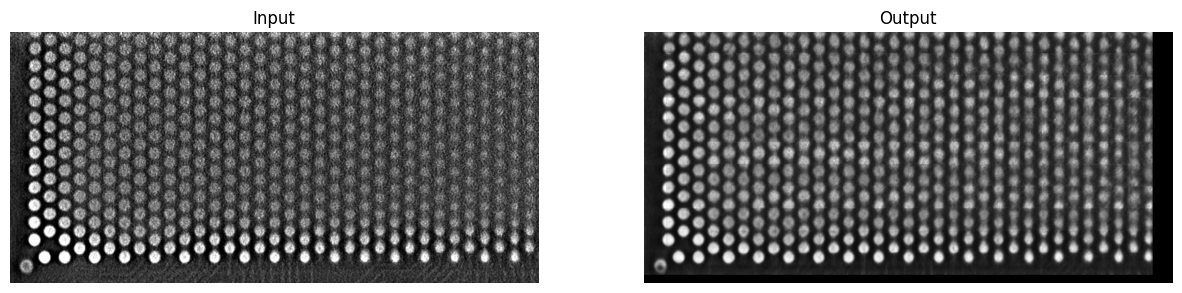

Saved: image1_ft.jpeg

Processing: image2.bmp
Image size: (2190, 1934)


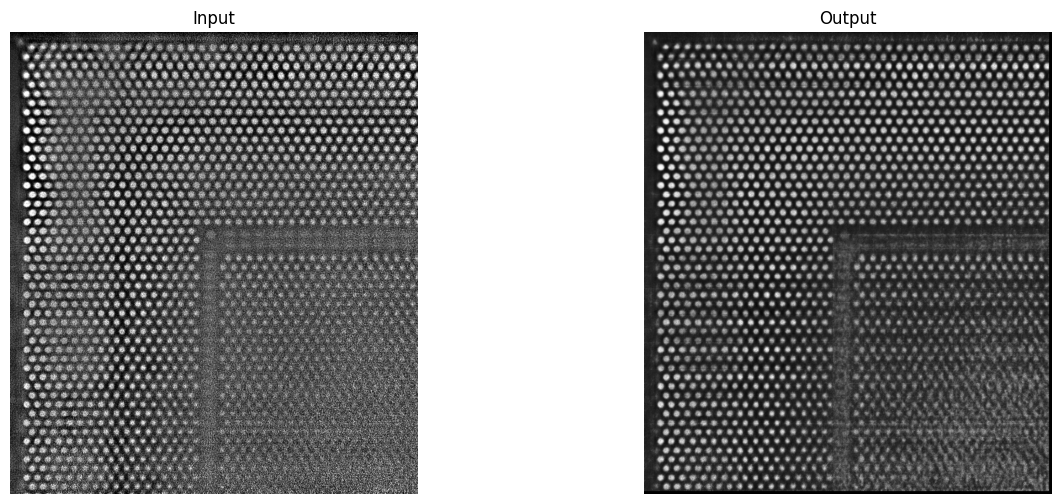

Saved: image2_ft.bmp


array([[34, 32, 30, ...,  0,  0,  0],
       [33, 33, 31, ...,  0,  0,  0],
       [34, 32, 31, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(2190, 1934), dtype=uint8)

In [3]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ======================================================
# 1. U-Net Model (same as training)
# ======================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = ConvBlock(1, 32)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = ConvBlock(32, 64)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = ConvBlock(64, 128)
        self.p3 = nn.MaxPool2d(2)

        self.d4 = ConvBlock(128, 256)
        self.p4 = nn.MaxPool2d(2)

        self.bn = ConvBlock(256, 512)

        self.u4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.c4 = ConvBlock(256 + 256, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.c3 = ConvBlock(128 + 128, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.c2 = ConvBlock(64 + 64, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.c1 = ConvBlock(32 + 32, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        d1 = self.d1(x); p1 = self.p1(d1)
        d2 = self.d2(p1); p2 = self.p2(d2)
        d3 = self.d3(p2); p3 = self.p3(d3)
        d4 = self.d4(p3); p4 = self.p4(d4)

        bn = self.bn(p4)

        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, d4], 1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, d3], 1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, d2], 1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, d1], 1))

        return self.out(c1)

# ======================================================
# 2. Load fine-tuned weights
# ======================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

model = UNet().to(device)

# remap keys if needed
ckpt = torch.load("unet_finetuned.pth", map_location=device)
fixed_ckpt = {k.replace("conv", "block"): v for k, v in ckpt.items()}
model.load_state_dict(fixed_ckpt, strict=False)

model.eval()
print("✔ Fine-tuned model loaded.")

# ======================================================
# 3. Function to apply overlap-based inference
# ======================================================
def run_unet_on_full_image(model, img_path, patch_size=128, overlap=64):
    print(f"\nProcessing: {img_path}")

    img = cv2.imread(img_path, 0)
    h, w = img.shape
    print("Image size:", img.shape)

    img_f = img.astype(np.float32) / 255.0

    out = np.zeros((h, w), np.float32)
    count = np.zeros((h, w), np.float32)

    for i in range(0, h - patch_size + 1, patch_size - overlap):
        for j in range(0, w - patch_size + 1, patch_size - overlap):
            patch = img_f[i:i+patch_size, j:j+patch_size]
            patch_t = torch.tensor(patch).unsqueeze(0).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(patch_t).cpu().squeeze().numpy()

            out[i:i+patch_size, j:j+patch_size] += pred
            count[i:i+patch_size, j:j+patch_size] += 1

    out = out / count
    out = np.clip(out * 255, 0, 255).astype(np.uint8)

    # show
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1); plt.title("Input"); plt.imshow(img, cmap='gray'); plt.axis('off')
    plt.subplot(1,2,2); plt.title("Output"); plt.imshow(out, cmap='gray'); plt.axis('off')
    plt.show()

    save_name = os.path.basename(img_path).replace(".", "_ft.")
    cv2.imwrite(save_name, out)
    print("Saved:", save_name)

    return out

# ======================================================
# 4. RUN for image1
# ======================================================
run_unet_on_full_image(model, "image1.jpeg")

# ======================================================
# 5. RUN for image2
# ======================================================
run_unet_on_full_image(model, "image2.bmp")


Loading weights...
✔ Model loaded successfully!
Processing: image1.jpeg
Image size: (728, 1531)


C:\Users\User\AppData\Local\Temp\ipykernel_15044\4292936745.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("unet_finetuned.pth", map_location=device)

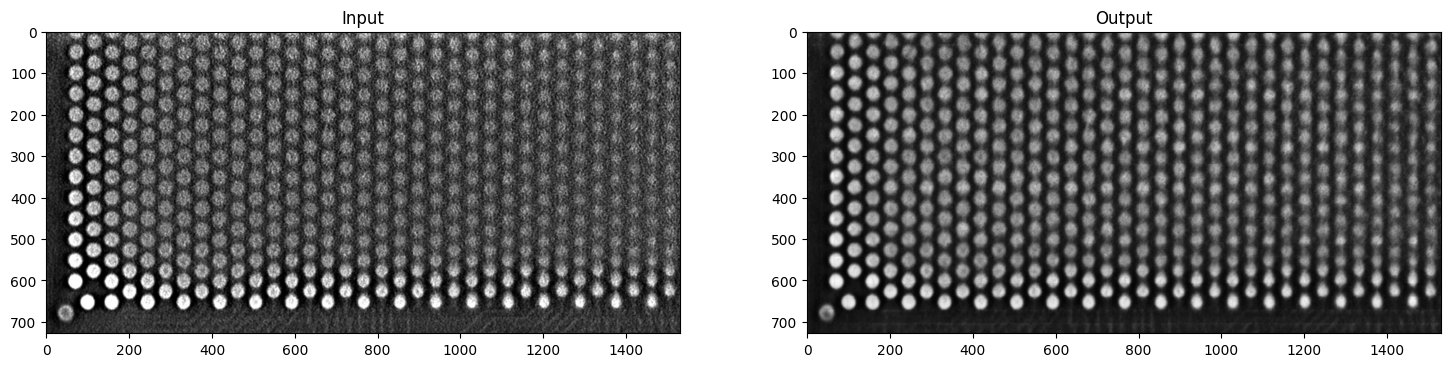

Saved: image1_ft_overlap.jpeg
Processing: image2.bmp
Image size: (2190, 1934)


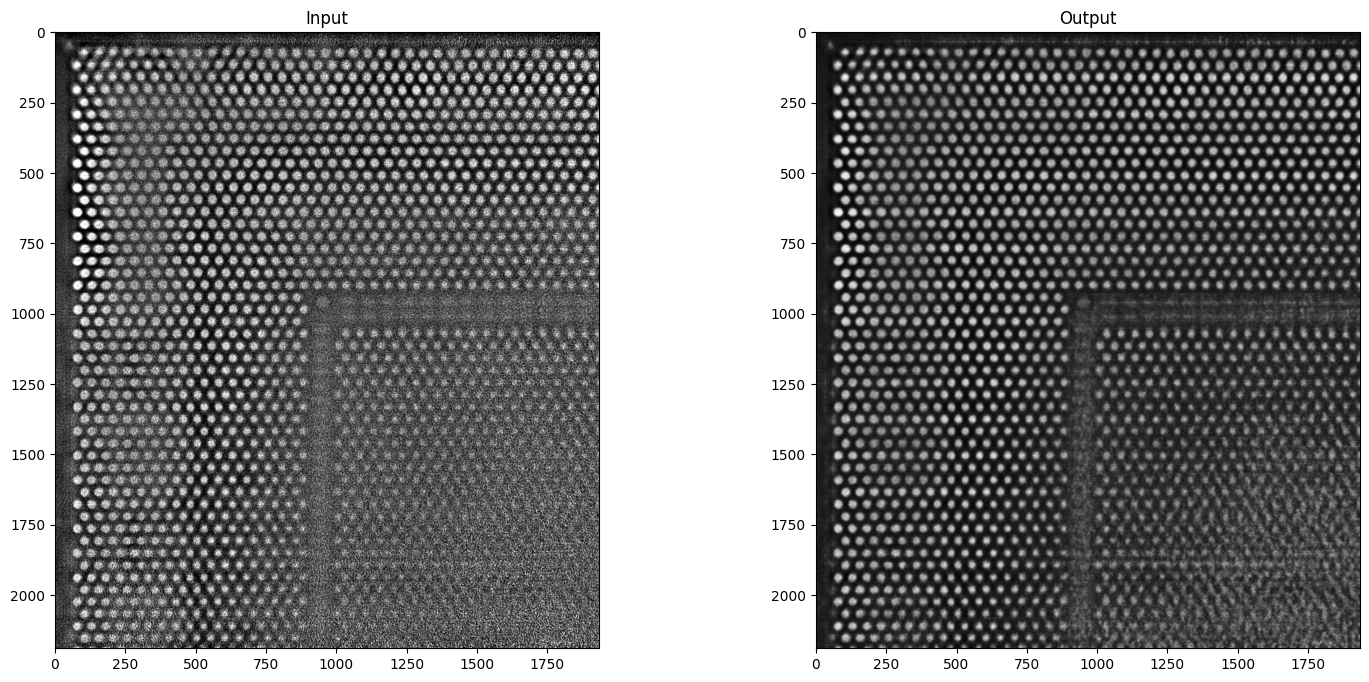

Saved: image2_ft_overlap.bmp


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # MATCHING YOUR TRAINING MODEL (32-64-128-256-512)
        self.d1 = ConvBlock(1, 32)
        self.d2 = ConvBlock(32, 64)
        self.d3 = ConvBlock(64, 128)
        self.d4 = ConvBlock(128, 256)
        self.bn = ConvBlock(256, 512)

        self.u4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.c4 = ConvBlock(512, 256)

        self.u3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.c3 = ConvBlock(256, 128)

        self.u2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.c2 = ConvBlock(128, 64)

        self.u1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.c1 = ConvBlock(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        c1 = self.d1(x)
        p1 = F.max_pool2d(c1, 2)

        c2 = self.d2(p1)
        p2 = F.max_pool2d(c2, 2)

        c3 = self.d3(p2)
        p3 = F.max_pool2d(c3, 2)

        c4 = self.d4(p3)
        p4 = F.max_pool2d(c4, 2)

        bn = self.bn(p4)

        u4 = self.u4(bn)
        c4 = self.c4(torch.cat([u4, c4], dim=1))

        u3 = self.u3(c4)
        c3 = self.c3(torch.cat([u3, c3], dim=1))

        u2 = self.u2(c3)
        c2 = self.c2(torch.cat([u2, c2], dim=1))

        u1 = self.u1(c2)
        c1 = self.c1(torch.cat([u1, c1], dim=1))

        return torch.sigmoid(self.out(c1))



# ============================================================
# 2) LOAD FINE-TUNED MODEL
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

print("Loading weights...")

# Load normally — NO key replacement, NO conv→block remapping
ckpt = torch.load("unet_finetuned.pth", map_location=device)

model.load_state_dict(ckpt, strict=True)

model.eval()
print("✔ Model loaded successfully!")


# ============================================================
# 3) SLIDING-WINDOW WITH OVERLAP BLENDING
# ============================================================
def infer_overlap(img, patch=128, overlap=96):
    h, w = img.shape
    out = np.zeros((h, w), dtype=np.float32)
    weight = np.zeros((h, w), dtype=np.float32)

    step = patch - overlap

    for y in range(0, h, step):
        for x in range(0, w, step):
            y1, y2 = y, min(y+patch, h)
            x1, x2 = x, min(x+patch, w)

            crop = img[y1:y2, x1:x2]

            # pad to patch size
            ch, cw = crop.shape
            pad = (
                (0, patch-ch),
                (0, patch-cw)
            )
            crop = np.pad(crop, pad, mode='reflect')

            # prepare tensor
            t = torch.from_numpy(crop/255.0).float().unsqueeze(0).unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(t).cpu().numpy()[0,0]

            pred = pred[:ch, :cw]

            out[y1:y2, x1:x2] += pred
            weight[y1:y2, x1:x2] += 1

    out = out / weight
    return (out*255).clip(0,255).astype(np.uint8)


# ============================================================
# 4) RUN ON ANY IMAGE
# ============================================================

def run_image(path, save_as=None):
    print("Processing:", path)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    print("Image size:", (h, w))

    out = infer_overlap(img)

    if save_as is None:
        save_as = path.replace(".", "_ft.")

    cv2.imwrite(save_as, out)

    # show results
    plt.figure(figsize=(18,8))
    plt.subplot(1,2,1); plt.title("Input"); plt.imshow(img, cmap='gray')
    plt.subplot(1,2,2); plt.title("Output"); plt.imshow(out, cmap='gray')
    plt.show()

    print("Saved:", save_as)


# ============================================================
# 5) RUN BOTH IMAGES
# ============================================================

run_image("image1.jpeg", "image1_ft_overlap.jpeg")
run_image("image2.bmp", "image2_ft_overlap.bmp")
